**Physics-Informed Neural Network for the Lorenz System**

This notebook generates Lorenz-system data and trains a PINN to recover both the trajectory and the physical parameters.

Lorenz equations:

`dx/dt = sigma * (y - x)`

`dy/dt = x * (rho - z) - y`

`dz/dt = x * y - beta * z`

The neural network predicts `[x(t), y(t), z(t)]`. PyTorch autograd computes the time derivatives, and the loss penalizes both data error and equation residuals.

In [1]:
import importlib.util

if importlib.util.find_spec('torch') is None:
    raise ImportError(
        "PyTorch is required for this PINN notebook. Install it in the project venv with:\n"
        "    venv\\Scripts\\python.exe -m pip install torch\n"
        "Then restart the notebook kernel and run again."
    )

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(7)
torch.manual_seed(7)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


**Generate Lorenz data**

This uses the same initial condition and parameters as `Lorentz.ipynb`, with a fourth-order Runge-Kutta integrator for cleaner training data.

In [2]:
tf = 5.0
dt = 0.001
steps = int(tf / dt)
t = np.arange(steps, dtype=np.float32).reshape(-1, 1) * dt

sigma_true = 10.0
rho_true = 28.0
beta_true = 3.0
x0 = np.array([-8.0, 7.0, 27.0], dtype=np.float32)

def lorenz_rhs(state, sigma=sigma_true, rho=rho_true, beta=beta_true):
    x, y, z = state
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z,
    ], dtype=np.float32)

states = np.zeros((steps, 3), dtype=np.float32)
states[0] = x0

for i in range(1, steps):
    s = states[i - 1]
    k1 = lorenz_rhs(s)
    k2 = lorenz_rhs(s + 0.5 * dt * k1)
    k3 = lorenz_rhs(s + 0.5 * dt * k2)
    k4 = lorenz_rhs(s + dt * k3)
    states[i] = s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

noise_std = 0.05
measured = states + noise_std * np.random.randn(*states.shape).astype(np.float32)

print('Data shape:', measured.shape)
print('True parameters:', {'sigma': sigma_true, 'rho': rho_true, 'beta': beta_true})

Data shape: (5000, 3)
True parameters: {'sigma': 10.0, 'rho': 28.0, 'beta': 3.0}


**Normalize data for stable neural-network training**

In [3]:
t_min = t.min()
t_max = t.max()
t_norm = 2.0 * (t - t_min) / (t_max - t_min) - 1.0

y_mean = measured.mean(axis=0, keepdims=True)
y_std = measured.std(axis=0, keepdims=True)
y_norm = (measured - y_mean) / y_std

t_train = torch.tensor(t_norm, dtype=torch.float32, device=device, requires_grad=True)
y_train = torch.tensor(y_norm, dtype=torch.float32, device=device)
y_mean_t = torch.tensor(y_mean, dtype=torch.float32, device=device)
y_std_t = torch.tensor(y_std, dtype=torch.float32, device=device)
dt_norm_dt = torch.tensor(2.0 / (t_max - t_min), dtype=torch.float32, device=device)

print('State mean:', y_mean.ravel())
print('State std:', y_std.ravel())

State mean: [-1.3142567 -1.2054377 23.480448 ]
State std: [8.237236 9.362671 8.699344]


**Define the Lorenz PINN**

`sigma`, `rho`, and `beta` are learned as positive trainable parameters.

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim=1, out_dim=3, hidden=64, depth=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class LorenzPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.state_net = MLP()
        self.softplus = nn.Softplus()

        # Initialized near common Lorenz values, but still learned from data.
        self.raw_sigma = nn.Parameter(torch.tensor(10.0))
        self.raw_rho = nn.Parameter(torch.tensor(28.0))
        self.raw_beta = nn.Parameter(torch.tensor(3.0))

    def parameters_physical(self):
        sigma = self.softplus(self.raw_sigma)
        rho = self.softplus(self.raw_rho)
        beta = self.softplus(self.raw_beta)
        return sigma, rho, beta

    def forward(self, t_in):
        y_hat_norm = self.state_net(t_in)
        y_hat = y_mean_t + y_std_t * y_hat_norm
        sigma, rho, beta = self.parameters_physical()
        return y_hat_norm, y_hat, sigma, rho, beta


model = LorenzPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

**Train the PINN**

The data loss fits the measured trajectory. The physics loss enforces the Lorenz differential equations on randomly sampled time points.

In [5]:
EPOCHS = 10000
PHYSICS_BATCH = 1024
lambda_data = 1.0
lambda_physics = 0.01

history = []

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    y_hat_norm, _, sigma, rho, beta = model(t_train)
    loss_data = torch.mean((y_hat_norm - y_train) ** 2)

    idx = torch.randint(0, steps, (min(PHYSICS_BATCH, steps),), device=device)
    t_phys = t_train[idx].clone().detach().requires_grad_(True)
    _, y_phys, sigma, rho, beta = model(t_phys)

    x = y_phys[:, 0:1]
    y = y_phys[:, 1:2]
    z = y_phys[:, 2:3]

    dx_dt_norm = torch.autograd.grad(x, t_phys, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    dy_dt_norm = torch.autograd.grad(y, t_phys, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    dz_dt_norm = torch.autograd.grad(z, t_phys, grad_outputs=torch.ones_like(z), create_graph=True)[0]

    dx_dt = dx_dt_norm * dt_norm_dt
    dy_dt = dy_dt_norm * dt_norm_dt
    dz_dt = dz_dt_norm * dt_norm_dt

    r1 = dx_dt - sigma * (y - x)
    r2 = dy_dt - (x * (rho - z) - y)
    r3 = dz_dt - (x * y - beta * z)
    loss_physics = torch.mean(r1 ** 2 + r2 ** 2 + r3 ** 2)

    loss = lambda_data * loss_data + lambda_physics * loss_physics
    loss.backward()
    optimizer.step()

    if epoch == 1 or epoch % 500 == 0:
        row = [epoch, loss.item(), loss_data.item(), loss_physics.item(), sigma.item(), rho.item(), beta.item()]
        history.append(row)
        print(
            f'Epoch {epoch:5d} | loss={loss.item():.6f} | data={loss_data.item():.6f} | '
            f'physics={loss_physics.item():.6f} | sigma={sigma.item():.4f} | '
            f'rho={rho.item():.4f} | beta={beta.item():.4f}'
        )

Epoch     1 | loss=50.956947 | data=0.998296 | physics=4995.865234 | sigma=10.0000 | rho=28.0000 | beta=3.0486
Epoch   500 | loss=1.571085 | data=1.566440 | physics=0.464512 | sigma=9.9743 | rho=27.9447 | beta=3.0051
Epoch  1000 | loss=1.559481 | data=1.555767 | physics=0.371397 | sigma=9.9743 | rho=27.8928 | beta=2.9655
Epoch  1500 | loss=1.543921 | data=1.540912 | physics=0.300996 | sigma=9.9743 | rho=27.8174 | beta=2.9070
Epoch  2000 | loss=1.525009 | data=1.522804 | physics=0.220569 | sigma=9.9741 | rho=27.7171 | beta=2.8277
Epoch  2500 | loss=1.496775 | data=1.494045 | physics=0.272992 | sigma=9.9736 | rho=27.5895 | beta=2.7257
Epoch  3000 | loss=1.464755 | data=1.457892 | physics=0.686289 | sigma=9.9732 | rho=27.4329 | beta=2.5990
Epoch  3500 | loss=1.426379 | data=1.423074 | physics=0.330490 | sigma=9.9727 | rho=27.2468 | beta=2.4459
Epoch  4000 | loss=1.386405 | data=1.382603 | physics=0.380196 | sigma=9.9715 | rho=27.0323 | beta=2.2668
Epoch  4500 | loss=1.337632 | data=1.3290

**Evaluate the learned trajectory and parameters**

In [6]:
model.eval()
with torch.no_grad():
    _, pred_t, sigma_hat, rho_hat, beta_hat = model(torch.tensor(t_norm, dtype=torch.float32, device=device))
    pred = pred_t.cpu().numpy()

rmse_measured = np.sqrt(np.mean((measured - pred) ** 2, axis=0))
rmse_clean = np.sqrt(np.mean((states - pred) ** 2, axis=0))

print('RMSE vs measured [x, y, z]:', rmse_measured)
print('RMSE vs clean    [x, y, z]:', rmse_clean)
print('\nTrue parameters:')
print(f'sigma={sigma_true:.6f}, rho={rho_true:.6f}, beta={beta_true:.6f}')
print('Learned parameters:')
print(f'sigma={sigma_hat.item():.6f}, rho={rho_hat.item():.6f}, beta={beta_hat.item():.6f}')

RMSE vs measured [x, y, z]: [6.5719476 7.792987  8.634315 ]
RMSE vs clean    [x, y, z]: [6.5722566 7.792401  8.633965 ]

True parameters:
sigma=10.000000, rho=28.000000, beta=3.000000
Learned parameters:
sigma=10.594304, rho=24.579090, beta=0.303969


**Plots**

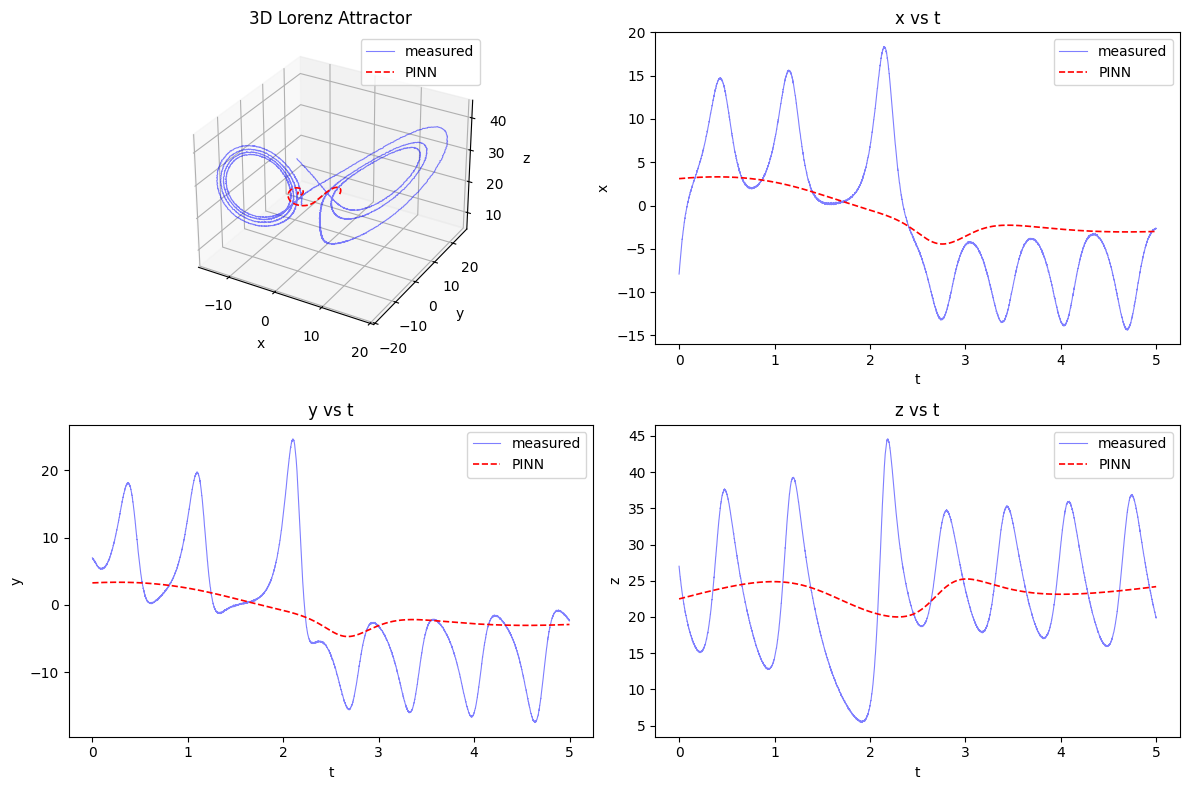

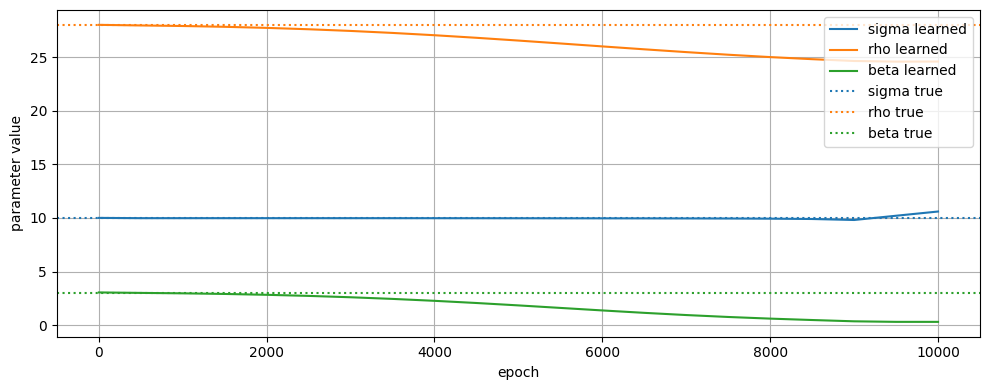

In [7]:
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(221, projection='3d')
ax1.plot(measured[:, 0], measured[:, 1], measured[:, 2], 'b', linewidth=0.8, alpha=0.5)
ax1.plot(pred[:, 0], pred[:, 1], pred[:, 2], 'r--', linewidth=1.2)
ax1.set_title('3D Lorenz Attractor')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.legend(['measured', 'PINN'])

ax2 = fig.add_subplot(222)
ax2.plot(t, measured[:, 0], 'b', linewidth=0.8, alpha=0.5)
ax2.plot(t, pred[:, 0], 'r--', linewidth=1.2)
ax2.set_title('x vs t')
ax2.set_xlabel('t')
ax2.set_ylabel('x')
ax2.legend(['measured', 'PINN'])

ax3 = fig.add_subplot(223)
ax3.plot(t, measured[:, 1], 'b', linewidth=0.8, alpha=0.5)
ax3.plot(t, pred[:, 1], 'r--', linewidth=1.2)
ax3.set_title('y vs t')
ax3.set_xlabel('t')
ax3.set_ylabel('y')
ax3.legend(['measured', 'PINN'])

ax4 = fig.add_subplot(224)
ax4.plot(t, measured[:, 2], 'b', linewidth=0.8, alpha=0.5)
ax4.plot(t, pred[:, 2], 'r--', linewidth=1.2)
ax4.set_title('z vs t')
ax4.set_xlabel('t')
ax4.set_ylabel('z')
ax4.legend(['measured', 'PINN'])

plt.tight_layout()
plt.show()

history_arr = np.array(history)
if len(history_arr) > 0:
    plt.figure(figsize=(10, 4))
    plt.plot(history_arr[:, 0], history_arr[:, 4], label='sigma learned')
    plt.plot(history_arr[:, 0], history_arr[:, 5], label='rho learned')
    plt.plot(history_arr[:, 0], history_arr[:, 6], label='beta learned')
    plt.axhline(sigma_true, color='C0', linestyle=':', label='sigma true')
    plt.axhline(rho_true, color='C1', linestyle=':', label='rho true')
    plt.axhline(beta_true, color='C2', linestyle=':', label='beta true')
    plt.grid()
    plt.xlabel('epoch')
    plt.ylabel('parameter value')
    plt.legend()
    plt.tight_layout()
    plt.show()

**Optional LBFGS refinement**

Run this cell after Adam training for a closer fit. It is slower because it evaluates the physics residual on all time points.

In [ ]:
RUN_LBFGS = False

if RUN_LBFGS:
    lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=500, tolerance_grad=1e-7, tolerance_change=1e-9)

    def closure():
        lbfgs.zero_grad()
        y_hat_norm, y_hat, sigma, rho, beta = model(t_train)
        loss_data = torch.mean((y_hat_norm - y_train) ** 2)

        x = y_hat[:, 0:1]
        y = y_hat[:, 1:2]
        z = y_hat[:, 2:3]
        dx_dt = torch.autograd.grad(x, t_train, grad_outputs=torch.ones_like(x), create_graph=True)[0] * dt_norm_dt
        dy_dt = torch.autograd.grad(y, t_train, grad_outputs=torch.ones_like(y), create_graph=True)[0] * dt_norm_dt
        dz_dt = torch.autograd.grad(z, t_train, grad_outputs=torch.ones_like(z), create_graph=True)[0] * dt_norm_dt

        r1 = dx_dt - sigma * (y - x)
        r2 = dy_dt - (x * (rho - z) - y)
        r3 = dz_dt - (x * y - beta * z)
        loss_physics = torch.mean(r1 ** 2 + r2 ** 2 + r3 ** 2)
        loss = lambda_data * loss_data + lambda_physics * loss_physics
        loss.backward()
        return loss

    final_loss = lbfgs.step(closure)
    print('Final LBFGS loss:', float(final_loss))